<font color='#4393C3' size='4'><b>Project goal:</b></font> Waze leadership has asked your data team to develop a machine learning model to predict user churn. Churn quantifies the number of users who have uninstalled the Waze app or stopped using the app. This project focuses on monthly user churn. An accurate model will help prevent churn, improve user retention, and grow Waze’s business.
This project is part of a larger effort at Waze to increase growth. Typically, high retention rates indicate satisfied users who repeatedly use the Waze app over time. Developing a churn prediction model will help prevent churn, improve user retention, and grow Waze’s business. If Waze can identify a segment of users who are at high risk of churning, Waze can proactively engage these users with special offers to try and retain them. Otherwise, Waze may lose these users without knowing why. 
Your insights will help Waze leadership optimize the company’s retention strategy, enhance user experience, and make data-driven decisions about product development.

<font color='#4393C3' size='4'><b>Background:</b></font> Waze’s free navigation app makes it easier for drivers around the world to get to where they want to go. Waze’s community of map editors, beta testers, translators, partners, and users helps make each drive better and safer. 

<font color='#4393C3' size='4'><b>Scenario:</b></font> Your team is in the early stages of their user churn project. Your project proposal has been approved and your team has been given access to Waze’s user data. To get clear insights, the data must first be inspected, organized, and prepared for analysis. 

To get clear insights, the data must first be <ins>inspected, organized, and prepared for analysis</ins>. 

<font color='#4393C3' size='4'><b>Tasks:</b></font> 
- Import data and build a dataframe 
- Examine data 
- Clean your data
- Gather descriptive statistics
- Perform exploratory data analysis
- Conduct hypothesis testing
- Create a data visualization
- Evaluate the results
- Prepare a summary

<font color='#4393C3' size='5' style="text-decoration: underline; text-decoration-color: blue;"><b>Import the Packages and Load The Data</b></font>

In [1]:
# unrelated to calculations 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [3]:
waze_data = pd.read_csv('/kaggle/input/waze-dataset-google-advanced-data-analytics-part-2/waze_dataset.csv')

<font color='#4393C3' size='5' style="text-decoration: underline; text-decoration-color: blue;"><b>Dataset Summary</b></font>

In [4]:
# Summary of the dataframe 
waze_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


**Dataset Description**: This dataset contains information about user engagement and driving data. It has **14999** rows (users) and **13** columns.

**Feature Descriptions**: 
- **ID** (a sequential numbered index)
- **label** (binary  variable: “retained” vs “churned”)
- **sessions** (number of times a user opened the app during the month)
- **drives** (number of times a drive longer than 1 km was taken during the month)
- **total_sessions** (a total number of sessions registered for a user)
- **n_days_after_onboarding** (the number of days since a user signed up for the app)
- **total_navigations_fav1** (total navigations since onboarding to the user’s favorite place 1)
- **total_navigations_fav2** (total navigations since onboarding to the user’s favorite place 2)
- **driven_km_drives** (total kilometers driven during the month)
- **duration_minutes_drives** (total duration driven in minutes during the month)
- **activity_days** (number of days a user opens the app during the month) 
- **driving_days** (number of days a drive longer than 1 km was taken during the month)
- **device** (type of device: iPhone or Android)

Since the main goal of the Waze project is to analyze data for insights into user churn, we can assume that a*ll columns — except **ID** — reflect user engagement* and are therefore relevant to this analysis. The **ID** column can be dropped, as we are not analyzing individual users.

<font color='#4393C3' size='5' style="text-decoration: underline; text-decoration-color: blue;"><b>Missing Data</b></font>

From the first part of our analysis, we found that the dataset has 700 missing 'label' entries, which are most likely missing completely at random (MCAR).

In [5]:
waze_data['label'].isnull().value_counts().reset_index()

,label,count
0,False,14299
1,True,700


<font color='#4393C3' size='5' style="text-decoration: underline; text-decoration-color: blue;"><b>Duplicates</b></font>


In [6]:
# Initial number of entries in the dataset
entries = waze_data.shape[0]
print(f'The dataset containes {entries} rows.')

# Number of entires left in the datast after removing duplicates, we don't want to mofify the dataset yet, so we omit inplace=True
entries_no_dupl = waze_data.drop_duplicates().shape[0]
print(f'After removing duplicates, the dataset has {entries_no_dupl} rows.')

The dataset containes 14999 rows.
After removing duplicates, the dataset has 14999 rows.


<font color='#4393C3' size='5' style="text-decoration: underline; text-decoration-color: blue;"><b>Ouliers</b></font>

The data will be checked for the outliers later in the visualisation part. 

<font color='#4393C3' size='5' style="text-decoration: underline; text-decoration-color: blue;"><b>Data overview and summary statistics</b></font>


In [7]:
# Preview of the of the dataset
waze_data.head(15)

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android
5,5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone
6,6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone
7,7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone
8,8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android
9,9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone


In [8]:
# Total number of elements in the dataset
waze_data.size

194987

In [9]:
# Summary statistics for the dataset
waze_data.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


<font color='#4393C3' size='5' style="text-decoration: underline; text-decoration-color: blue;"><b>Data Visualisation</b></font>

Here we focuse on visualizing the distribution of important parameters in the dataset that might shed light on user engagement. We will use boxplots and histograms to better understand data patterns and identify potential trends or outliers.

<font color='#4393C3' size='4'><b>Sessions Data</b>

The session column shows the number of times a user opened the app in the last month. 

The session variable does not follow a normal distribution. The histigram shows that the distibution is right-skewed, while the meadian is at 56, some users open the app as much as 700 times.

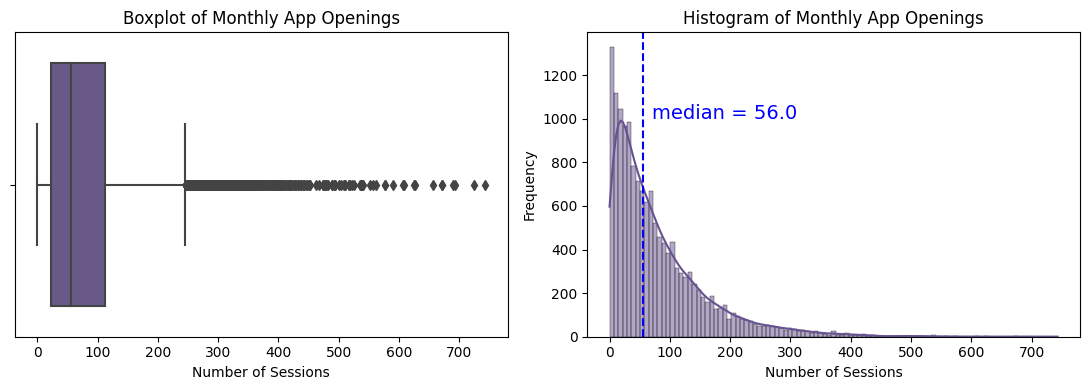

In [10]:
# A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0])
sns.boxplot(x=waze_data['sessions'], color = '#665191', ax=axes[0])
axes[0].set_title("Boxplot of Monthly App Openings")
axes[0].set_xlabel("Number of Sessions")

# Histogram on the second axis (axes[1])
sns.histplot(waze_data['sessions'], color = '#665191', kde=True, ax=axes[1])
median = waze_data['sessions'].median()
plt.axvline(median, color='blue', linestyle='--')
plt.text(70,1000,'median = 56.0', color='blue', size = 14)
axes[1].set_title("Histogram of Monthly App Openings")
axes[1].set_xlabel("Number of Sessions")
axes[1].set_ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Drives Data</b>

The 'drives' column shows the number of times a drive longer than 1 km was taken during the month.

The distribution of the drives data is similar to that of the sessions data, it is right-skewed as well. The median number of drives is 48, though some drivers made over 500 drives last month.

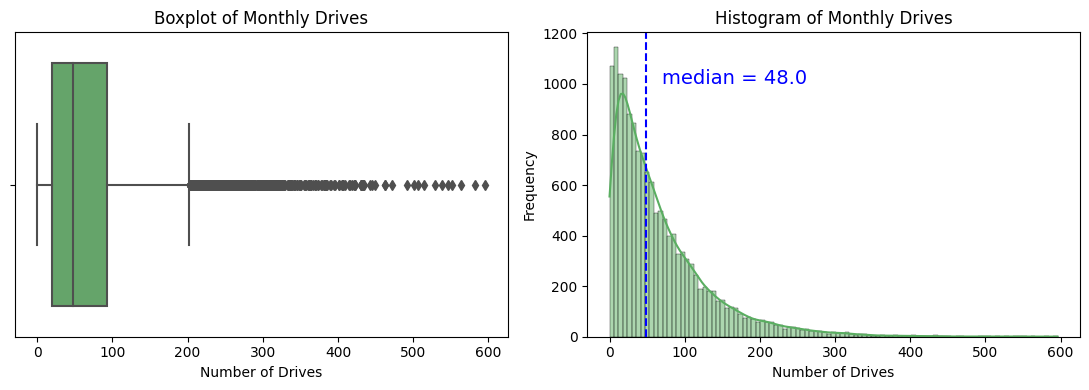

In [11]:
# A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0])
sns.boxplot(x=waze_data['drives'], color = '#5AAE61', ax=axes[0])
axes[0].set_title("Boxplot of Monthly Drives")
axes[0].set_xlabel("Number of Drives")

# Histogram on the second axis (axes[1])
sns.histplot(waze_data['drives'],color = '#5AAE61', kde=True, ax=axes[1])
median = waze_data['drives'].median()
plt.axvline(median, color='blue', linestyle='--')
plt.text(70,1000,'median = 48.0', color='blue', size = 14)
axes[1].set_title("Histogram of Monthly Drives")
axes[1].set_xlabel("Number of Drives")
axes[1].set_ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Total Sessions Data</b>


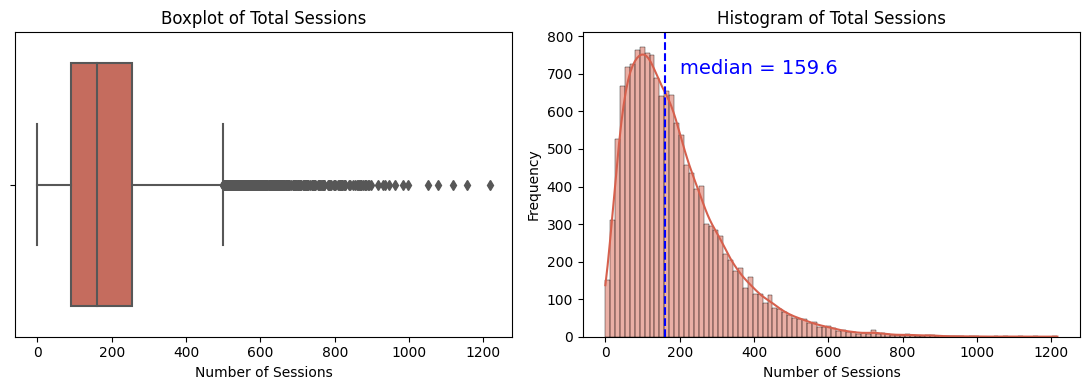

In [12]:
# A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0])
sns.boxplot(x=waze_data['total_sessions'], color = '#D6604D', ax=axes[0])
axes[0].set_title("Boxplot of Total Sessions")
axes[0].set_xlabel("Number of Sessions")

# Histogram on the second axis (axes[1])
sns.histplot(waze_data['total_sessions'], color = '#D6604D',kde=True, ax=axes[1])
median = waze_data['total_sessions'].median()
plt.axvline(median, color='blue', linestyle='--')
plt.text(200,700,'median = 159.6', color='blue', size = 14)
axes[1].set_title("Histogram of Total Sessions")
axes[1].set_xlabel("Number of Sessions")
axes[1].set_ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Days After Onboarding Data</b>


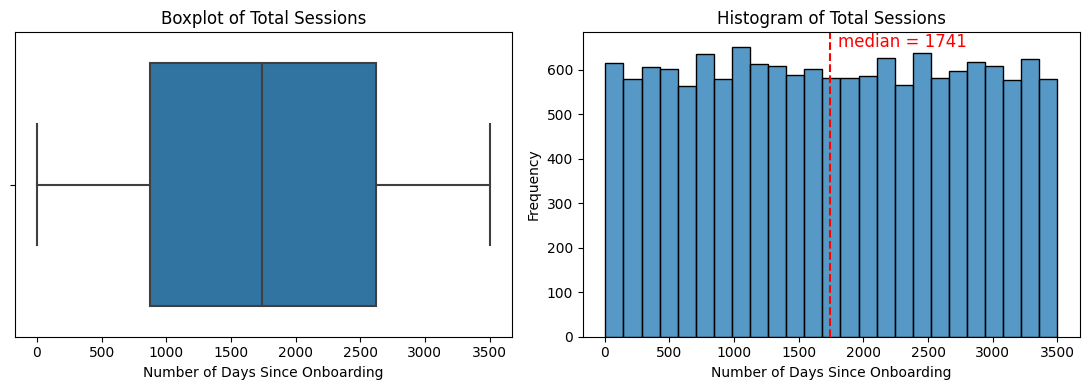

In [13]:
# A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0])
sns.boxplot(x=waze_data['n_days_after_onboarding'], ax=axes[0])
axes[0].set_title("Boxplot of Total Sessions")
axes[0].set_xlabel("Number of Days Since Onboarding")

# Histogram on the second axis (axes[1])
sns.histplot(waze_data['n_days_after_onboarding'], ax=axes[1])
median = waze_data['n_days_after_onboarding'].median()
plt.axvline(median, color='red', linestyle='--')
plt.text(1800,650,'median = 1741', color='red', size = 12)
axes[1].set_title("Histogram of Total Sessions")
axes[1].set_xlabel("Number of Days Since Onboarding")
axes[1].set_ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Total Distance Data</b>

The 'driven_km_drives' variable represents the total kilometers driven over the month. The distribution is right-skewed, with half of the users driving less than approximately 3,450 km. However, some users drove more than 20,000 km (high-mileage drivers).

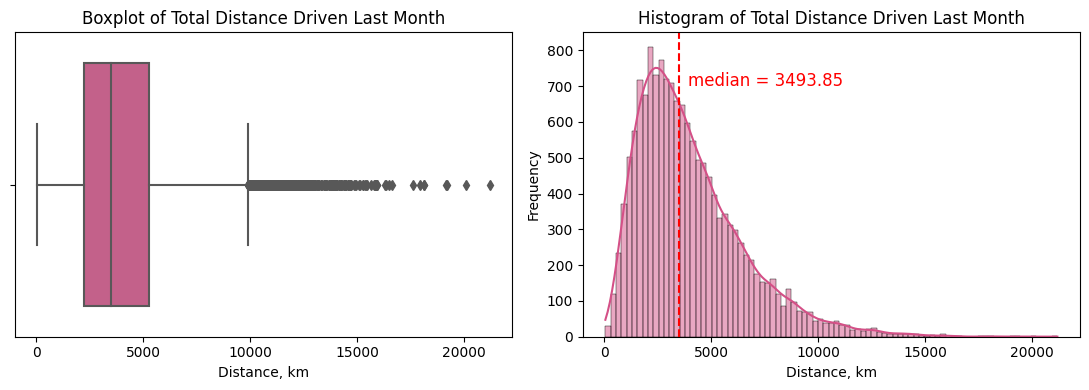

In [14]:
# A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0])
sns.boxplot(x=waze_data['driven_km_drives'], color = '#d45087', ax=axes[0])
axes[0].set_title("Boxplot of Total Distance Driven Last Month")
axes[0].set_xlabel("Distance, km")

# Histogram on the second axis (axes[1])
sns.histplot(waze_data['driven_km_drives'], color = '#d45087', kde=True, ax=axes[1])
median = waze_data['driven_km_drives'].median()
plt.axvline(median, color='red', linestyle='--')
plt.text(3900,700,'median = 3493.85', color='red', size = 12)
axes[1].set_title("Histogram of Total Distance Driven Last Month")
axes[1].set_xlabel("Distance, km")
axes[1].set_ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Total Time Driven Data</b>

The 'duration_minutes_drives' variable represents the total driving duration over the month. The distribution is right-skewed, with half of the users driving less than approximately 25 hours. However, some users logged up to 250 hours of driving time.

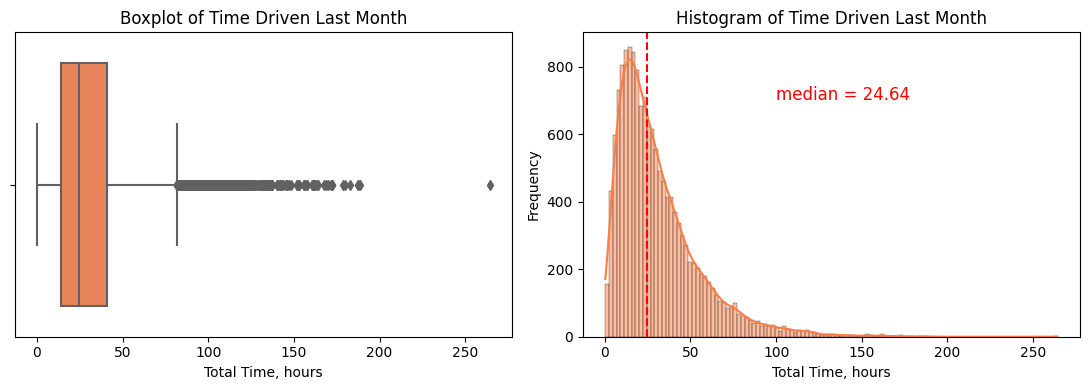

In [15]:
# A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0])
sns.boxplot(x=waze_data['duration_minutes_drives']/60, color = '#ff7c43', ax=axes[0])
axes[0].set_title("Boxplot of Time Driven Last Month")
axes[0].set_xlabel("Total Time, hours")

# Histogram on the second axis (axes[1])
sns.histplot(waze_data['duration_minutes_drives']/60, color = '#ff7c43', kde=True, ax=axes[1])
median = waze_data['duration_minutes_drives'].median()
plt.axvline(median/60, color='red', linestyle='--')
plt.text(100,700,'median = 24.64', color='red', size = 12)
axes[1].set_title("Histogram of Time Driven Last Month")
axes[1].set_xlabel("Total Time, hours")
axes[1].set_ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Activity Days Data</b>

The 'activity_days' column represents number of days a user opens the app during the month. The histogram shows an almost uniform distribution. Each day ~500 users open the app (aside from a few exceptions). The 'sessions' column shows the number of times a user opened the app in the last month and we could assume, that 'activity_days' follows the similar distibution pattern. However, 'activity_days' does not mirror the right-skewed distribution of sessions.


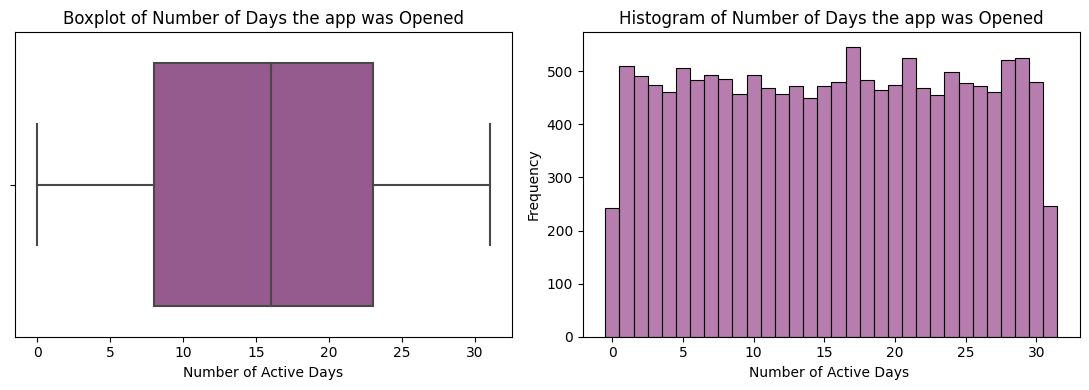

In [16]:
#A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0])
sns.boxplot(x=waze_data['activity_days'], color = '#a05195', ax=axes[0])
axes[0].set_title("Boxplot of Number of Days the app was Opened")
axes[0].set_xlabel("Number of Active Days")

# Histogram on the second axis (axes[1]). discrete=True ensures that bins align with whole numbers
sns.histplot(waze_data['activity_days'], discrete=True, color = '#a05195', ax=axes[1])
axes[1].set_title("Histogram of Number of Days the app was Opened")
axes[1].set_xlabel("Number of Active Days ")
axes[1].set_ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Driving Days Data</b>

The 'driving_days' column represents the number of times a drive longer than 1 km was taken during the month. The distribution is almost uniform. Resembles the distibution of 'activity_days'. However, there were ~250 users who didn't open the app at all on certain days and 'driving_days' data show us that ~ 1000 users didn't drive more that 1 km over the last month.

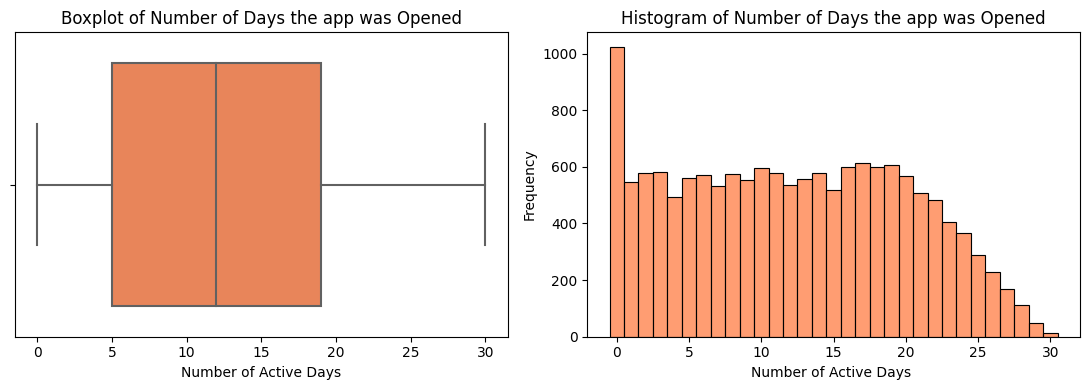

In [17]:
#A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0])
sns.boxplot(x=waze_data['driving_days'], color = '#ff7c43', ax=axes[0])
axes[0].set_title("Boxplot of Number of Days the app was Opened")
axes[0].set_xlabel("Number of Active Days")

# Histogram on the second axis (axes[1]). discrete=True ensures that bins align with whole numbers
sns.histplot(waze_data['driving_days'], discrete=True, color = '#ff7c43', ax=axes[1])
axes[1].set_title("Histogram of Number of Days the app was Opened")
axes[1].set_xlabel("Number of Active Days ")
axes[1].set_ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Device Data</b>

Users use either iPhone or Android to access the app. From the pie chart we can see that we have twice as many iPhone users.

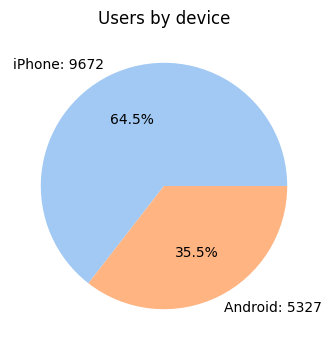

In [18]:
# Pie chart
fig = plt.figure(figsize=(4,4))
colors = sns.color_palette("pastel")
data=waze_data['device'].value_counts()
plt.pie(data, colors = colors,
labels=[f'{data.index[0]}: {data.values[0]}',
f'{data.index[1]}: {data.values[1]}'],
autopct='%1.1f%%')
plt.title('Users by device');

<font color='#4393C3' size='4'><b>Retained vs. Churned</b>

Label is a binary parameter shoing us wherether a user is churned or retained. From the pie chart we can see that ~ 18% of users are churned, while ~ 82% are retained.

Text(0.5, 1.0, 'Retained vs. Churned')

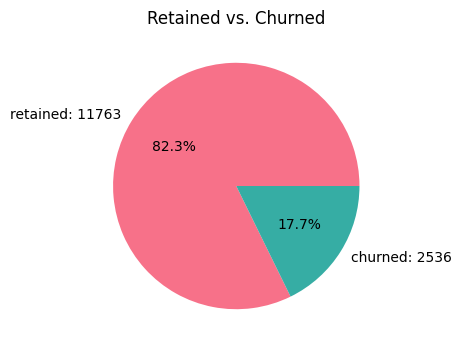

In [19]:
fig = plt.figure(figsize=(4,4))
colors = sns.color_palette("husl", 2)
data=waze_data['label'].value_counts()
plt.pie(data, colors = colors,
labels=[f'{data.index[0]}: {data.values[0]}',
f'{data.index[1]}: {data.values[1]}'],
autopct='%1.1f%%')
plt.title('Retained vs. Churned')

Text(0.5, 1.0, 'Device/Retention Dependence Histogram')

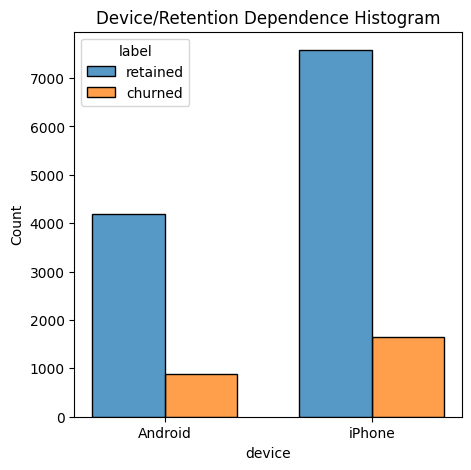

In [20]:
# The proportion of retained vs. churned users device-wise 
fig = plt.figure(figsize=(5,5))
sns.histplot(data = waze_data, x = 'device', hue = 'label',multiple='dodge', shrink=0.7)
plt.title("Device/Retention Dependence Histogram")

The proportion of retains vs. churned users is aproximately equal for both device types (4.6-4.7:1).

<font color='#4393C3' size='4'><b>Mean Distance per Driving Day</b>

We can demonstate the dependence of the retention rate on the mean distance a driver makes over the month. For this we need to create a new column 'km_per_driving_day'. Some values in this column will be 'inf' because a drive is only recorded if it exceeds 1 km. If any of the drives a driver makes over the month is less than 1 km, then the 'drives' column remains 0 while other columns are still updated, leading to division by zero. The situation can be fixed by replacing infinite values with zeros.

In [21]:
# Create a new column 'km_per_driving_day'. 
waze_data['km_per_driving_day'] = waze_data['driven_km_drives'] / waze_data['driving_days']

# check the result with describe().
waze_data['km_per_driving_day'].describe()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

In [22]:
# replace all positive and negative infinity values are replaced with 0. 'inplace=True' modifies an original dataframe. 
waze_data['km_per_driving_day'].replace([np.inf, -np.inf], 0, inplace=True)

# check the result with describe().
waze_data['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

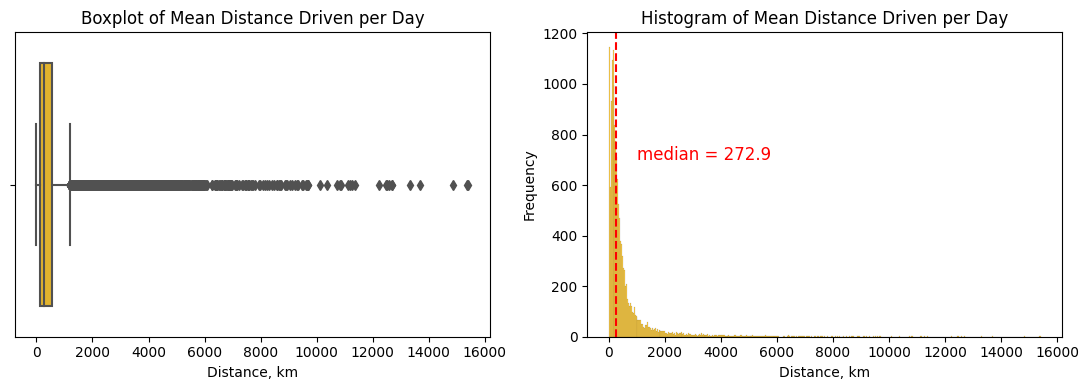

In [23]:
#A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0])
sns.boxplot(x=waze_data['km_per_driving_day'], color = '#ffc110', ax=axes[0])
axes[0].set_title("Boxplot of Mean Distance Driven per Day")
axes[0].set_xlabel("Distance, km")

# Histogram on the second axis (axes[1]). discrete=True ensures that bins align with whole numbers
sns.histplot(waze_data['km_per_driving_day'], color = '#ffc110', ax=axes[1])
axes[1].set_title("Histogram of Mean Distance Driven per Day")
median = waze_data['km_per_driving_day'].median()
plt.axvline(median, color='red', linestyle='--')
plt.text(1000,700,'median = 272.9', color='red', size = 12)
axes[1].set_xlabel("Distance, km")
axes[1].set_ylabel("Frequency")

# Show the plots
plt.tight_layout()
plt.show()

The median of 'km_per_driving_day' is ~ 273 km. However, the maximum value of a distance driven per day is 15420 km (!). For context, a driver could cover a maximum of 2,400 km in a day if they drove non-stop at 100 km/h for 24 hours. 
We can identiify outliers in our dataset with Interquartile Range Method and then filter out the rows which are below or above an upper bond and a lower bond.

In [24]:
# Calculating Q1, Q3, and IQR
Q1 = np.percentile(waze_data['km_per_driving_day'], 25)
Q3 = np.percentile(waze_data['km_per_driving_day'], 75)
IQR = Q3 - Q1
lower_bond = Q1 - 1.5 * IQR
upper_bond = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bond:.2f}")
print(f"Upper Bound: {upper_bond:.2f}")



Q1: 136.24
Q3: 558.69
IQR: 422.45
Lower Bound: -497.43
Upper Bound: 1192.36


If we filter the data before plotting the graphs, the upper and lower bounds will shift because the plotted data changes. For now let's just zoom in on our data by setting limits for X-axis.

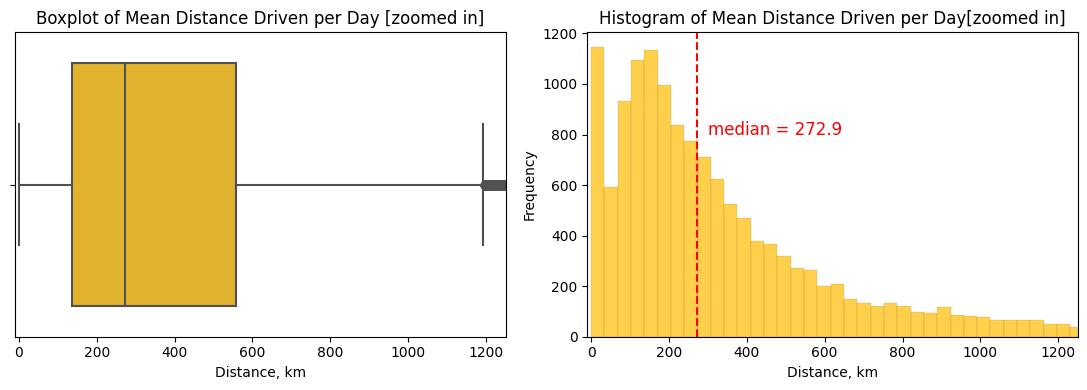

In [25]:
#A figure with wo subplots (one row, two columns)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot on the first axis (axes[0]) 
sns.boxplot(x=waze_data['km_per_driving_day'], color = '#ffc110', ax=axes[0])
axes[0].set_title("Boxplot of Mean Distance Driven per Day [zoomed in]")
axes[0].set_xlabel("Distance, km")

#setting a limit for X-axis based on the upper limit value 
axes[0].set_xlim(-10, 1250) 

# Histogram on the second axis (axes[1]). discrete=True ensures that bins align with whole numbers
sns.histplot(waze_data['km_per_driving_day'], color = '#ffc110', ax=axes[1])
axes[1].set_title("Histogram of Mean Distance Driven per Day[zoomed in]")
median = waze_data['km_per_driving_day'].median()
plt.axvline(median, color='red', linestyle='--')
plt.text(300,800,'median = 272.9', color='red', size = 12)
axes[1].set_xlabel("Distance, km")
axes[1].set_ylabel("Frequency")

#setting a limit for X-axis based on the upper limit value 
axes[1].set_xlim(-10, 1250) 

# Show the plots
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Retention by Mean Distance per Driving Day</b>

Let's demonstrate the mean distance driven per day for retained vs. churned users. From a histogram we can see that, as the average distance traveled per day increases, the percentage of churned users rises accordingly.

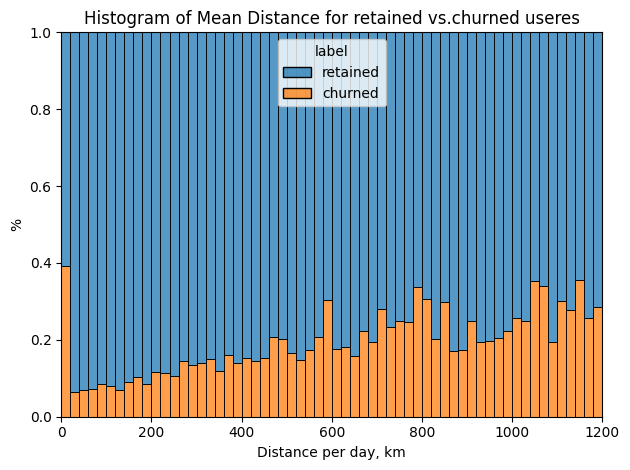

In [26]:
sns.histplot(data = waze_data, x = 'km_per_driving_day', bins=range(0,1201,20), hue='label', multiple='fill')
plt.title("Histogram of Mean Distance for retained vs.churned useres")
plt.xlabel("Distance per day, km")
plt.ylabel("%")
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Retention Rate vs. Driving Days</b>

If we plot a histogram of churn rate versus the number of driving days over the month, we observe that 40% of churned users did not drive at all during this period. Moreover, the more frequently users recorded trips longer than 1 km, the lower their churn rate. This suggests that drivers who use the app more often are less likely to churn. Notably, users who engaged with the app every day throughout the month (31 days) did not churn at all.
We can assume that churn rate is not solely an indicator of user dissatisfaction with the app but rather reflects reasons unrelated to app usability.

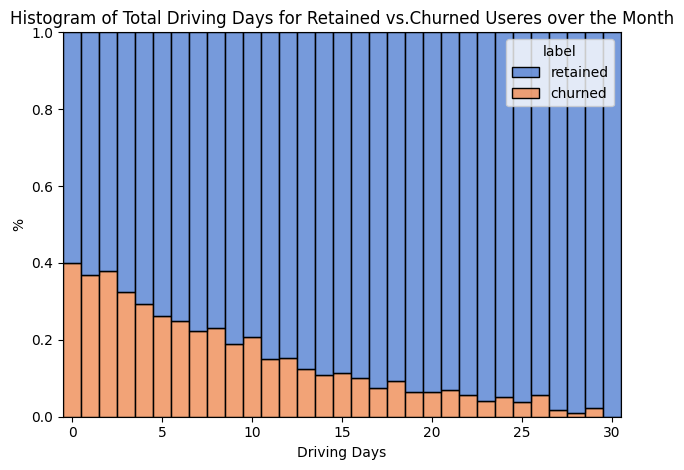

In [27]:
colors = sns.color_palette("husl", 2)
sns.histplot(data = waze_data, x = 'driving_days', discrete = True, hue='label', multiple='fill', palette="muted")
plt.title("Histogram of Total Driving Days for Retained vs.Churned Useres over the Month")
plt.xlabel("Driving Days")
plt.ylabel("%")
plt.tight_layout()
plt.show()

<font color='#4393C3' size='4'><b>Total Sessions vs. Last Month Sessions</b>

By calculating the proportion of times a user opened the app in the last month relative to the total number of app openings, we find that the median value is approximately 0.4. At the same time, the median time since onboarding is 1,741 days (about 5 years!). In summary, over the past month, users engaged in 40% or more of the total sessions, while the average user has been active on the app for around 5 years.

In [28]:
# new column represention the proportion of the session occured over the last month
waze_data['percent_session_last_month'] = waze_data['sessions'] / waze_data['total_sessions']

# descriptive statistis for a new column
waze_data['percent_session_last_month'].describe()

count    14999.000000
mean         0.449255
std          0.286919
min          0.000000
25%          0.196221
50%          0.423097
75%          0.687216
max          1.530637
Name: percent_session_last_month, dtype: float64

In [29]:
# descriprive statistics for the 'n_days_after_onboarding' column
waze_data['n_days_after_onboarding'].describe()

count    14999.000000
mean      1749.837789
std       1008.513876
min          4.000000
25%        878.000000
50%       1741.000000
75%       2623.500000
max       3500.000000
Name: n_days_after_onboarding, dtype: float64

Text(0.5, 1.0, 'Session Proportion in the Last Month vs. Total Sessions')

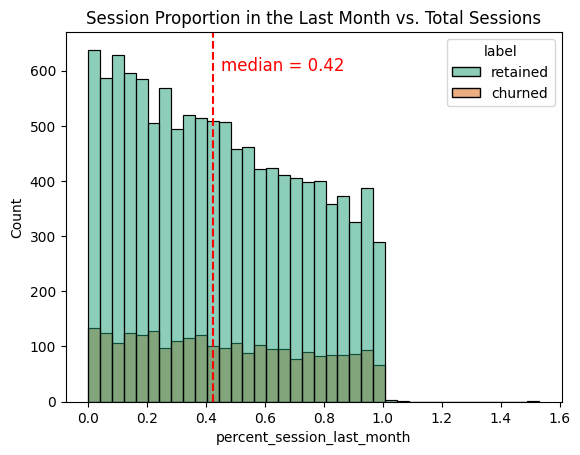

In [30]:
# histogram for a new column
sns.histplot(data = waze_data, x = 'percent_session_last_month', hue = 'label', palette="Dark2")
median = waze_data['percent_session_last_month'].median()
plt.axvline(median, color='red', linestyle='--')
plt.text(0.45,600,'median = 0.42', color='red', size = 12)
plt.title("Session Proportion in the Last Month vs. Total Sessions")


<font color='#4393C3' size='4'><b>Drives Data for iPhone vs. Android users</b>

Since we have two device types - iPhone and Adroid - we can perform two sample t-test to determite if there is a statistically significant difference in the average 'drives' data. Any difference could be an indication of a potential platform-based behaviours and different optimization for iOS and Android, which may affect user engegment and experience.

(array([0, 1]), [Text(0, 0, 'Android'), Text(0, 1, 'iPhone')])

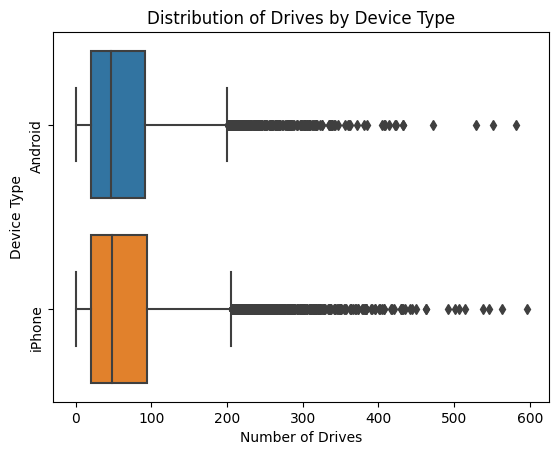

In [31]:
# we can first visualize the distribution of 'drives' data for iPhone and Android using a boxplot
sns.boxplot(data = waze_data, x = 'drives', y = 'device')
plt.title('Distribution of Drives by Device Type')
plt.xlabel('Number of Drives')
plt.ylabel('Device Type')
plt.yticks(rotation=90)

In [32]:
# Let's turn a categorial variable 'device' into a numerical one
# We can create a dictionary with a 'iPhone' and 'Android' as keys
map_dictionary = {'iPhone' : 1,
                  'Android' : 2}

#create a new column 'device_type', which is a copy of 'device' column as of now
waze_data['device_type'] = waze_data['device']

#Transform values in the new column with the map() method
waze_data['device_type'] = waze_data['device_type'].map(map_dictionary)

#Check the result
waze_data[['device','device_type']].head()

,device,device_type
0,Android,2
1,iPhone,1
2,Android,2
3,iPhone,1
4,Android,2


In [33]:
# Let's show discriptive statistics for two device types
waze_data.groupby('device_type')['drives'].mean().reset_index()

,device_type,drives
0,1,67.859078
1,2,66.231838


While the mean 'drives' values differ slightly between two device types, the difference might arise from a random sampling. We can conduct a hypothesis testing to check whether or not the difference is statistically significant.


STEP 1: State the null hypothesis and the alternative hypothesis 
* ($H_0$): there is NO statistical differences between mean number of drives between 'iPhone' and 'Android' users
* ($H_A$): there is a statistical differences between mean number of drives between 'iPhone' and 'Android' users

STEP 2: Chose a significance level 
* 5%

STEP 3: Find the p-value

STEP 4: Reject or fail to reject the null hypothesi

In [34]:
# Isolate 'drives' data for iPhone
iphone = waze_data[waze_data['device_type'] == 1]

# Isolate 'drives' data for Android
android = waze_data[waze_data['device_type'] == 2]

In [35]:
# 3. Compute a p-value. We assume unequal variances
stats.ttest_ind(a=iphone['drives'], b=android['drives'], equal_var=False)

TtestResult(statistic=1.463523206885235, pvalue=0.143351972680206, df=11345.066049381952)

With a p-value (0.143) being more than 0.05 (as our significance level is 5%), we fail to reject the null hypothesis in favor of the alternative hypothesis. So we can conclude that there is no statistically significant difference in the average number of drives between iPhone and Android users

<font color='#4393C3' size='5' style="text-decoration: underline; text-decoration-color: blue;"><b>Conclusions</b></font>

1. The analysis reveals that approximately 18% of users churned, while around 82% remained retained.
2. The analysis of mean daily distance shows that larger distances are positively correlated with a higher churn rate. At the same time, we observe a negative correlation between driving days and churn rate: the more frequently users engage with the app and record trips longer than 1 km, the lower their likelihood of churning.
3. Nearly all variables exhibit a right-skewed distribution, indicating that for most users, the parameter values fall towards the lower end of the range for each variable.
4. There is no statistically significant difference in the average number of drives between iPhone and Android users.